# TEMPEST_RAD Retrieval Analysis

This notebook performs retrieval simulations and analysis using the TEMPEST_RAD simulator.
It covers:
1.  Running TEMPEST (if needed) to generate thermal models.
2.  Comparing Smooth vs. Rough Brightness Temperatures.
3.  Spectral Analysis of individual facets.
4.  Bolometric Phase Curve analysis.
5.  Simulating an Instrument Observation (Flux integration over FOV).

In [18]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import shutil

# Ensure we can import from TEMPEST_RAD and src
# Adjust path to root directory relative to this notebook
current_dir = Path(os.getcwd()).resolve()
if current_dir.name == 'TEMPEST_RAD':
    root_dir = current_dir.parent
else:
    # Fallback if running from root
    root_dir = current_dir

# CHANGE WORKING DIRECTORY TO ROOT
# This ensures relative paths in config.yaml (like data/shape_models/...) work correctly
os.chdir(root_dir)
print(f"Working Directory set to: {os.getcwd()}")

sys.path.append(str(root_dir))

from src.utilities.config import Config
from src.utilities.utils import rotate_vector
from matplotlib.collections import PolyCollection
from TEMPEST_RAD.simulator import (
    load_shape_model, 
    compute_geometry, 
    RoughnessLUT, 
    planck_function, 
    rms_to_fraction, 
    calculate_theta
)

Working Directory set to: /Users/duncan/Desktop/DPhil/TEMPEST


## 1. Setup & Run TEMPEST

Define paths and run the core thermal model to generate surface temperatures.

In [19]:
# Define paths
CONFIG_PATH = os.path.join(root_dir, "private/data/config/moon/moon_config.yaml")
OUTPUT_DIR = os.path.join(root_dir, "output/retrieval_analysis")
LUT_PATH = os.path.join(root_dir, "roughness_lut_spectral_v1.h5")

print(f"--- Step 1: Running TEMPEST Simulation ---")
print(f"Config: {CONFIG_PATH}")
print(f"Output: {OUTPUT_DIR}")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Load Config and Shape Model FIRST to know what we expect
config = Config(CONFIG_PATH)
facets_expected, _ = load_shape_model(config.path_to_shape_model_file)
n_facets_expected = len(facets_expected)
print(f"Current Configuration expects {n_facets_expected} facets.")

# Find latest run
def get_latest_run_dir():
    base_out = os.path.join(root_dir, "output")
    if not os.path.exists(base_out): return None
    runs = [os.path.join(base_out, d) for d in os.listdir(base_out) if d.startswith("run_")]
    if not runs: return None
    return max(runs, key=os.path.getmtime)

print("Checking for existing TEMPEST runs...")
latest_run = get_latest_run_dir()
run_needed = True

if latest_run:
    temp_file = os.path.join(latest_run, "temperatures.csv")
    if os.path.exists(temp_file):
        # Check dimensions to ensure it matches current shape model
        try:
            # Load full file to check shape (safer than heuristic)
            temp_data = np.loadtxt(temp_file, delimiter=',')
            
            # Check if dimensions match n_facets_expected
            # TEMPEST output is usually (N_facets, N_timesteps) or transposed
            rows = temp_data.shape[0]
            cols = temp_data.shape[1] if len(temp_data.shape) > 1 else 1
            
            if rows == n_facets_expected or cols == n_facets_expected:
                print(f"Found compatible existing run: {latest_run}")
                shutil.copy(temp_file, os.path.join(OUTPUT_DIR, "temperatures.csv"))
                run_needed = False
            else:
                print(f"Existing run {latest_run} has shape {temp_data.shape}, but expected {n_facets_expected} facets. Re-running.")
        except Exception as e:
            print(f"Error checking existing run: {e}. Re-running.")
    else:
         print(f"Run folder {latest_run} found but no temperatures.csv. Re-running.")

if run_needed:
    print("Running TEMPEST... (this may take a moment)")
    cmd = ["python", "tempest.py", "--config", CONFIG_PATH]
    subprocess.run(cmd, check=True)
    
    # Get the new latest run
    latest_run = get_latest_run_dir()
    print(f"New run created at: {latest_run}")
    shutil.copy(os.path.join(latest_run, "temperatures.csv"), os.path.join(OUTPUT_DIR, "temperatures.csv"))


--- Step 1: Running TEMPEST Simulation ---
Config: /Users/duncan/Desktop/DPhil/TEMPEST/private/data/config/moon/moon_config.yaml
Output: /Users/duncan/Desktop/DPhil/TEMPEST/output/retrieval_analysis
Checking for existing TEMPEST runs...
Using existing run: /Users/duncan/Desktop/DPhil/TEMPEST/output/run_2026-02-13_14-15-00


## 2. Load Data

Load the shape model, temperatures, and the Roughness Lookup Table (LUT).

In [20]:
print(f"--- Step 2: Loading Data ---")
config = Config(CONFIG_PATH)
facets, mesh = load_shape_model(config.path_to_shape_model_file)
n_facets = len(facets)

# Load Temperatures
temps_path = os.path.join(OUTPUT_DIR, "temperatures.csv")
try:
    temps_all = np.loadtxt(temps_path, delimiter=',')
except ValueError:
    temps_all = np.loadtxt(temps_path, delimiter=',', skiprows=1)

# Handle Transpose if needed
if temps_all.shape[0] != n_facets and temps_all.shape[1] == n_facets:
    temps_all = temps_all.T

print(f"Loaded temperatures: {temps_all.shape}")

# Load LUT
theta = calculate_theta(config)
print(f"Calculated Theta: {theta:.3f}")
lut = RoughnessLUT(LUT_PATH, target_theta=theta, target_rms=90.0) # Load spectral LUT

# Helper to get temps at a specific time
def get_temps_at_time(time_hours):
    period = getattr(config, 'rotation_period_hours', 24.0)
    n_steps = temps_all.shape[1]
    idx = int((time_hours % period) / period * n_steps)
    idx = np.clip(idx, 0, n_steps - 1)
    return temps_all[:, idx]

--- Step 2: Loading Data ---
Loaded temperatures: (80, 360)
Calculated Theta: 0.028
LUT: Selected Theta=1.0 (Target=0.02762983430898598)
LUT: Using 'opening_angle' axis.
LUT: Selected Angle=90.0 (Target=90.0)


## 3. Analysis: Brightness Temp Maps

Compare Smooth vs. Rough bolometric brightness temperature maps for a specific time and phase.

--- Step 3: Generating Brightness Temperature Maps ---


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_8584/229246441.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


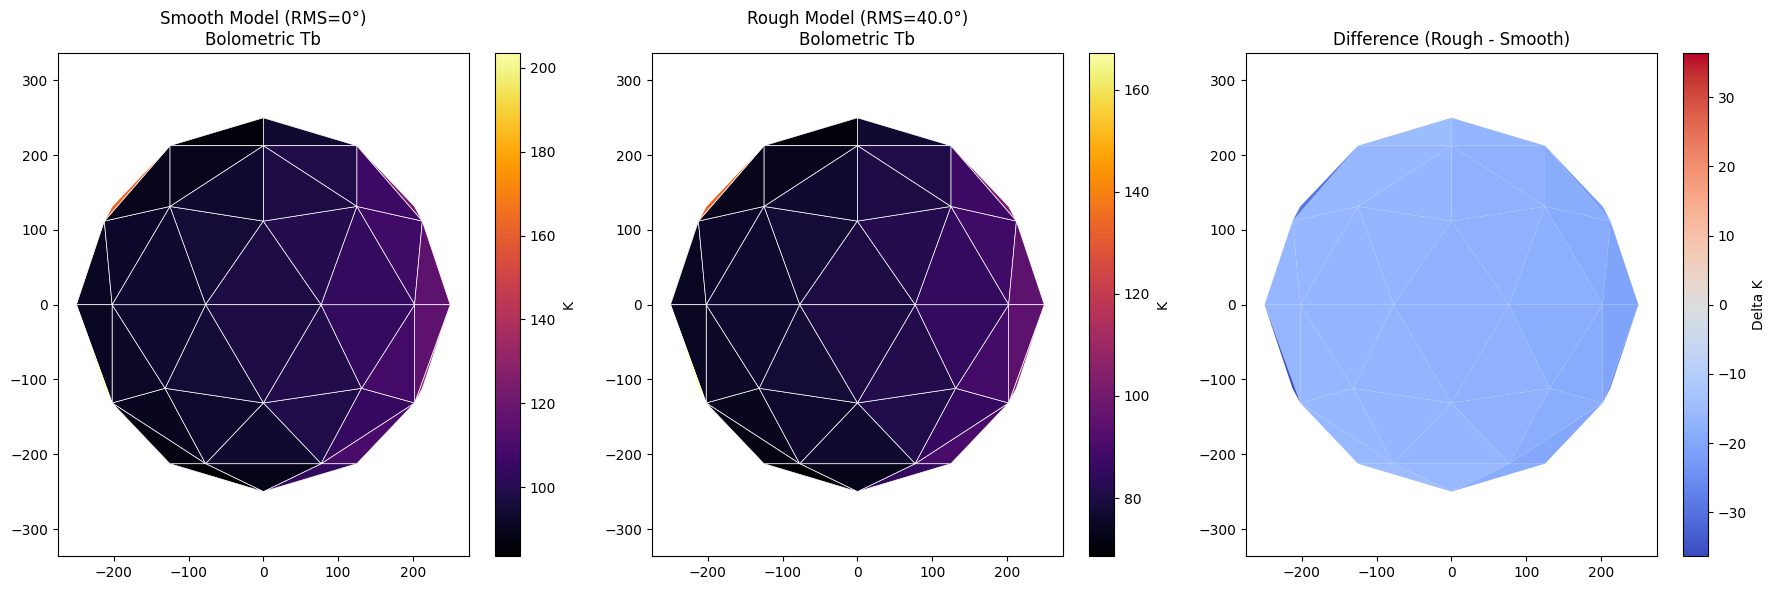

In [ ]:
print(f"--- Step 3: Generating Brightness Temperature Maps ---")

def calculate_bolometric_tb(time_hours, roughness_rms, phase_angle):
    # Geometry
    sun_vec = np.array(config.sunlight_direction)
    rot_axis = np.array([0, 0, 1]) # Simplified
    
    # Observer Vector
    perp_vec = np.cross(sun_vec, rot_axis)
    if np.linalg.norm(perp_vec) < 1e-6: perp_vec = np.array([0, 1, 0])
    obs_vec = rotate_vector(sun_vec, perp_vec, np.radians(phase_angle))
    
    lats, phases, emis, azis = compute_geometry(facets, sun_vec, obs_vec, rot_axis)
    
    # Temps
    temps_smooth = get_temps_at_time(time_hours)
    
    # Roughness
    f = rms_to_fraction(roughness_rms)
    
    # Wavelength Loop
    wavelengths = lut.axes['wavelength']
    full_spectra = np.zeros((n_facets, len(wavelengths)))
    
    for i, wave in enumerate(wavelengths):
        rad_smooth = planck_function(wave, temps_smooth)
        factors = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)
        full_spectra[:, i] = rad_smooth * ((1.0 - f) + f * factors)
        
    # Integrate
    rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)
    sigma = 5.670374419e-8
    t_eff = (np.pi * rad_bol / sigma) ** 0.25
    
    # Mask hidden
    t_eff[emis > 90] = 0
    
    return t_eff, obs_vec, emis

# Compare at Time=12h, Phase=30
time_tgt = 12.0
phase_tgt = 0.0

roughness_rms = 40.0

tb_smooth, obs_vec, emis = calculate_bolometric_tb(time_tgt, 0.0, phase_tgt)
tb_rough, _, _ = calculate_bolometric_tb(time_tgt, roughness_rms, phase_tgt)

# Projection for plotting (Wireframe)
def project_polys(obs_vec, mesh_vectors):
    obs_n = obs_vec / np.linalg.norm(obs_vec)
    up = np.array([0, 0, 1])
    if abs(np.dot(up, obs_n)) > 0.9: up = np.array([1, 0, 0])
    u = np.cross(obs_n, up); u /= np.linalg.norm(u)
    v = np.cross(obs_n, u)
    
    # Project vertices (N, 3, 3)
    u_verts = np.dot(mesh_vectors, u)
    v_verts = np.dot(mesh_vectors, v)
    return np.stack((u_verts, v_verts), axis=2)

polys = project_polys(obs_vec, mesh.vectors)
mask = emis < 90

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Smooth
coll1 = PolyCollection(polys[mask], array=tb_smooth[mask], cmap='inferno', edgecolors='white', linewidths=0.5)
axes[0].add_collection(coll1)
axes[0].set_title(f"Smooth Model (RMS=0°)\nBolometric Tb")
axes[0].autoscale()
axes[0].axis('equal')
plt.colorbar(coll1, ax=axes[0], label="K")

# Plot Rough
coll2 = PolyCollection(polys[mask], array=tb_rough[mask], cmap='inferno', edgecolors='white', linewidths=0.5)
axes[1].add_collection(coll2)
axes[1].set_title(f"Rough Model (RMS={roughness_rms}°)\nBolometric Tb")
axes[1].autoscale()
axes[1].axis('equal')
plt.colorbar(coll2, ax=axes[1], label="K")

# Plot Difference
diff = tb_rough - tb_smooth
vmax = np.max(np.abs(diff[mask]))
coll3 = PolyCollection(polys[mask], array=diff[mask], cmap='coolwarm', edgecolors='face', linewidths=0.0)
coll3.set_clim(-vmax, vmax)
axes[2].add_collection(coll3)
axes[2].set_title(f"Difference (Rough - Smooth)")
axes[2].autoscale()
axes[2].axis('equal')
plt.colorbar(coll3, ax=axes[2], label="Delta K")

plt.tight_layout()
plt.show()

## 4. Analysis: Spectral Comparison

Examine the spectral radiance for a single facet (e.g., sub-solar) to see deviations from a Planck function.

--- Step 4: Spectral Analysis ---
Selected Facet 62 (Sub-solar alignment: 0.987)


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_8584/153495597.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol_smooth = np.trapz(spec_smooth, x=wavelengths)
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_8584/153495597.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol_rough = np.trapz(spec_rough, x=wavelengths)


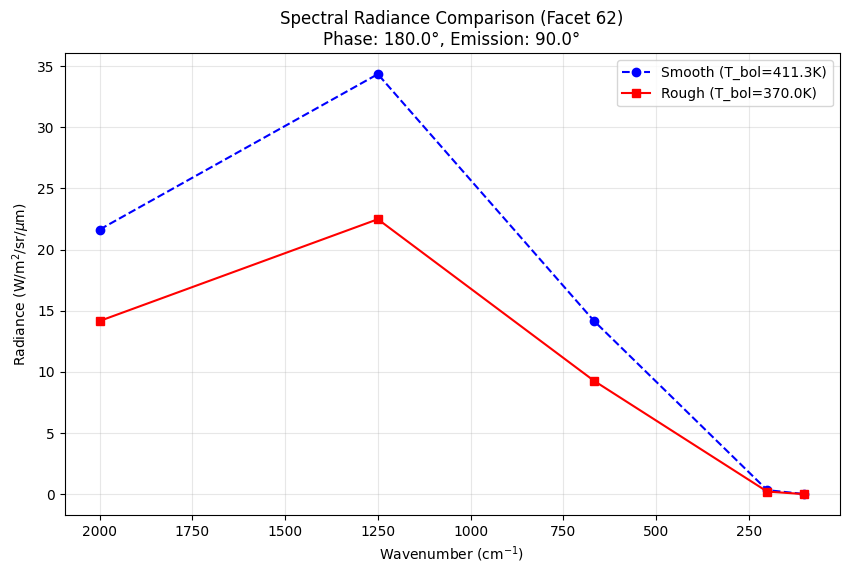

In [46]:
print(f"--- Step 4: Spectral Analysis ---")

# Pick a warm facet (e.g., closest to sub-solar point)
sun_vec = np.array(config.sunlight_direction)
centers = np.array([f.center for f in facets])
dots = np.dot(centers / np.linalg.norm(centers, axis=1)[:, None], sun_vec / np.linalg.norm(sun_vec))
target_facet_idx = np.argmax(dots)

print(f"Selected Facet {target_facet_idx} (Sub-solar alignment: {dots[target_facet_idx]:.3f})")

# Calculate Spectra
wavelengths = lut.axes['wavelength']
temps_smooth_val = get_temps_at_time(time_tgt)[target_facet_idx]

# Smooth Spectrum (Planck)
spec_smooth = planck_function(wavelengths, temps_smooth_val)

# Rough Spectrum
# Need geometry for this specific facet
lats, phases, emis, azis = compute_geometry([facets[target_facet_idx]], sun_vec, obs_vec, np.array([0,0,1]))
f = rms_to_fraction(28.0)

spec_rough = np.zeros_like(spec_smooth)
for i, wave in enumerate(wavelengths):
    rad_s = planck_function(wave, temps_smooth_val)
    factor = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)[0]
    spec_rough[i] = rad_s * ((1.0 - f) + f * factor)

# Calculate Bolometric Temps
rad_bol_smooth = np.trapz(spec_smooth, x=wavelengths)
sigma = 5.670374419e-8
t_eff_smooth = (np.pi * rad_bol_smooth / sigma) ** 0.25

rad_bol_rough = np.trapz(spec_rough, x=wavelengths)
t_eff_rough = (np.pi * rad_bol_rough / sigma) ** 0.25

# Convert to Wavenumber
wavenumbers = 10000.0 / wavelengths # cm^-1

# Plot
plt.figure(figsize=(10, 6))
plt.plot(wavenumbers, spec_smooth, 'o--', label=f'Smooth (T_bol={t_eff_smooth:.1f}K)', color='blue')
plt.plot(wavenumbers, spec_rough, 's-', label=f'Rough (T_bol={t_eff_rough:.1f}K)', color='red')

plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Radiance (W/m$^2$/sr/$\\mu$m)")
plt.title(f"Spectral Radiance Comparison (Facet {target_facet_idx})\nPhase: {phase_tgt}°, Emission: {emis[0]:.1f}°")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.show()

## 5. Analysis: Phase Curve Variation

Calculate the mean disk brightness temperature across varied phase angles.

--- Step 5: Phase Curve Analysis ---


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_8584/229246441.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


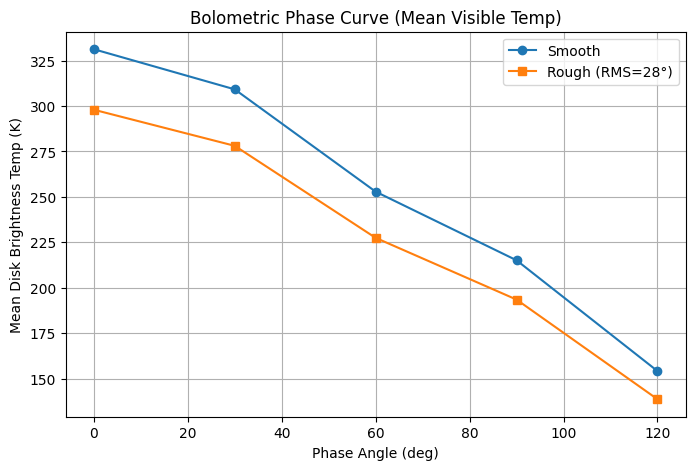

In [47]:
print(f"--- Step 5: Phase Curve Analysis ---")

phases_to_test = [0, 30, 60, 90, 120]
mean_temps_smooth = []
mean_temps_rough = []

for p in phases_to_test:
    # Calculate maps
    tb_s, _, emi_s = calculate_bolometric_tb(time_tgt, 0.0, p)
    tb_r, _, emi_r = calculate_bolometric_tb(time_tgt, 28.0, p)
    
    # Average over visible disk (simple mean for now, ideally area-weighted)
    mask_s = emi_s < 90
    mask_r = emi_r < 90
    
    mean_temps_smooth.append(np.mean(tb_s[mask_s]))
    mean_temps_rough.append(np.mean(tb_r[mask_r]))

plt.figure(figsize=(8, 5))
plt.plot(phases_to_test, mean_temps_smooth, 'o-', label='Smooth')
plt.plot(phases_to_test, mean_temps_rough, 's-', label='Rough (RMS=28°)')
plt.xlabel("Phase Angle (deg)")
plt.ylabel("Mean Disk Brightness Temp (K)")
plt.title("Bolometric Phase Curve (Mean Visible Temp)")
plt.legend()
plt.grid(True)
plt.show()

## 6. Simulated Instrument Observation (FOV)

Simulate a spacecraft instrument with a specific Field of View (FOV) and distance, integrating the flux from all visible facets within that FOV.

--- Step 6: Simulated Instrument Observation ---
Instrument FOV: 5.0° at 2000.0km
Facets in FOV and Visible: 40


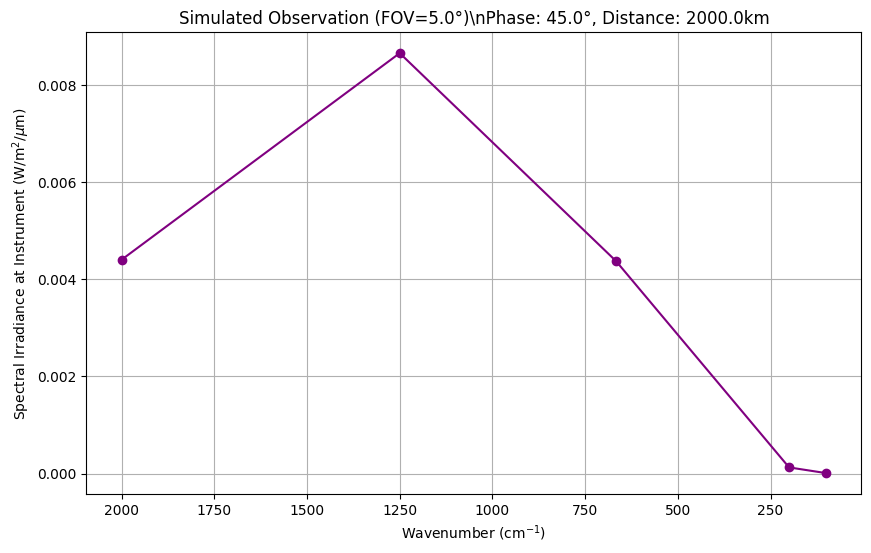


--- Analysis Complete ---


In [48]:
print(f"--- Step 6: Simulated Instrument Observation ---")

# Define Instrument
inst_dist = 2000.0 # km
inst_phase = 45.0
fov_deg = 5.0 # Narrow FOV

# Calculate Position
sun_vec = np.array(config.sunlight_direction)
rot_axis = np.array([0, 0, 1])
perp_vec = np.cross(sun_vec, rot_axis)
if np.linalg.norm(perp_vec) < 1e-6: perp_vec = np.array([0, 1, 0])
obs_dir = rotate_vector(sun_vec, perp_vec, np.radians(inst_phase))
obs_dir /= np.linalg.norm(obs_dir)
inst_pos = obs_dir * inst_dist * 1000 # meters

# Boresight (looking at center)
boresight = -obs_dir

# Find facets in FOV
centers = np.array([f.center for f in facets]) # meters
vecs_to_facets = centers - inst_pos # Vector from Inst to Facet
dists = np.linalg.norm(vecs_to_facets, axis=1)
vecs_norm = vecs_to_facets / dists[:, None]

# Angle from boresight
# dot(v, boresight) = cos(theta)
cos_thetas = np.dot(vecs_norm, boresight)
thetas = np.degrees(np.arccos(np.clip(cos_thetas, -1.0, 1.0)))

in_fov = (thetas < (fov_deg / 2.0))

# Check visibility (Emission < 90)
# Need normal vectors
normals = np.array([f.normal for f in facets])
# View vector is -vecs_norm (Facet to Inst)
cos_emis = np.einsum('ij,ij->i', normals, -vecs_norm)
visible = cos_emis > 0

valid_mask = in_fov & visible
valid_indices = np.where(valid_mask)[0]

print(f"Instrument FOV: {fov_deg}° at {inst_dist}km")
print(f"Facets in FOV and Visible: {len(valid_indices)}")

if len(valid_indices) > 0:
    # Integrate Spectrum
    # Flux Density = Sum ( Radiance * Solid_Angle )
    # Solid Angle = Area * cos(emi) / dist^2
    
    areas = np.array([f.area for f in facets])[valid_mask]
    dists_sq = dists[valid_mask]**2
    cos_e = cos_emis[valid_mask]
    solid_angles = areas * cos_e / dists_sq
    
    # Get Rough Radiance for these facets
    # Re-use logic (simplified for this block)
    lats, phases, emis, azis = compute_geometry(
        [facets[i] for i in valid_indices], 
        sun_vec, obs_dir, rot_axis
    )
    
    temps_fov = get_temps_at_time(time_tgt)[valid_mask]
    
    obs_spectrum = np.zeros(len(wavelengths))
    
    for i, wave in enumerate(wavelengths):
        rad_s = planck_function(wave, temps_fov)
        factors = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)
        rad_r = rad_s * ((1.0 - f) + f * factors)
        
        # Sum (Radiance * Solid Angle)
        obs_spectrum[i] = np.sum(rad_r * solid_angles)
        
# Convert to Wavenumber
    wavenumbers = 10000.0 / wavelengths # cm^-1

    # Plot Observed Spectrum
    plt.figure(figsize=(10, 6))
    plt.plot(wavenumbers, obs_spectrum, 'o-', color='purple')
    plt.xlabel("Wavenumber (cm$^{-1}$)")
    plt.ylabel("Spectral Irradiance at Instrument (W/m$^2$/$\\mu$m)")
    plt.title(f"Simulated Observation (FOV={fov_deg}°)\\nPhase: {inst_phase}°, Distance: {inst_dist}km")
    plt.grid(True)
    plt.gca().invert_xaxis()
    plt.show()
else:
    print("No facets visible in FOV.")

print("\n--- Analysis Complete ---")

## 7. Validation: Physics Checks

### What should happen to a sphere at zero phase?

**Theory:** At zero phase angle (Observer aligned with Sun), a rough surface should appear **warmer** than a smooth surface due to **Thermal Beaming**. 

- **Smooth Surface:** Temperature distribution typically follows a Lambertian-like profile (hottest at sub-solar point, cooling towards limb).
- **Rough Surface:** The observer sees the illuminated interiors of craters/roughness elements. Shadows are hidden behind the illuminated slopes. These interiors are hotter than the average surface because they trap heat (self-heating) and face the sun more directly locally. This concentrates ("beams") thermal emission back towards the source (the Sun/Observer).

**Expectation:** 
1. **Zero Phase:** $T_{rough} > T_{smooth}$
2. **Limb Darkening:** Roughness should reduce the severity of limb darkening (flatten the profile) compared to a smooth model.

--- Step 7: Validation Tests ---

[Test 1] Zero Phase Beaming Check
Mean Disk Temp @ Phase 0°:
  Smooth: 331.24 K
  Rough:  297.96 K
  Diff:   -33.28 K
❌ FAIL: Rough model is not warmer

[Test 2] Limb Darkening Profile (Temp vs Emission Angle)


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_8584/229246441.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


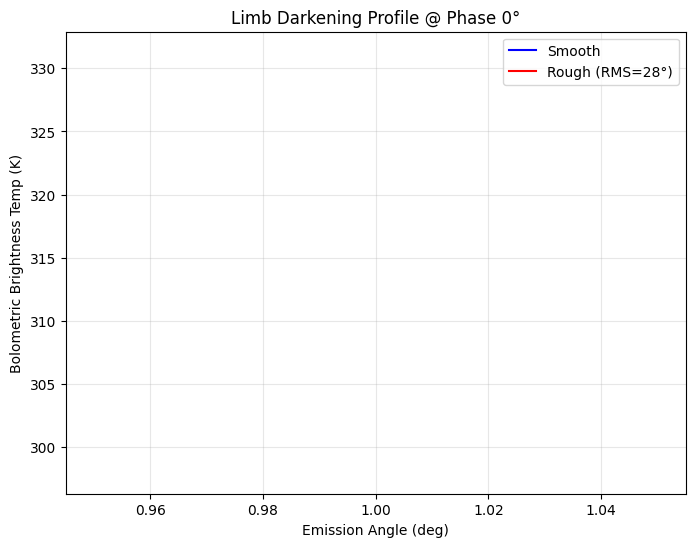

In [49]:
print("--- Step 7: Validation Tests ---")

# Test 1: Zero Phase Beaming Check
print("\n[Test 1] Zero Phase Beaming Check")
tb_smooth_0, _, emis_0 = calculate_bolometric_tb(time_tgt, 0.0, 0.0)
tb_rough_0, _, _ = calculate_bolometric_tb(time_tgt, 28.0, 0.0)

# Mask hidden
mask_0 = emis_0 < 90

mean_s_0 = np.mean(tb_smooth_0[mask_0])
mean_r_0 = np.mean(tb_rough_0[mask_0])

print(f"Mean Disk Temp @ Phase 0°:")
print(f"  Smooth: {mean_s_0:.2f} K")
print(f"  Rough:  {mean_r_0:.2f} K")
print(f"  Diff:   {mean_r_0 - mean_s_0:.2f} K")

if mean_r_0 > mean_s_0:
    print("✅ PASS: Rough model is warmer (Beaming detected)")
else:
    print("❌ FAIL: Rough model is not warmer")

# Test 2: Limb Darkening Profile
print("\n[Test 2] Limb Darkening Profile (Temp vs Emission Angle)")

# Bin emission angles to get a clean profile
bins = np.arange(0, 91, 2)
bin_centers = (bins[:-1] + bins[1:]) / 2
profile_s = []
profile_r = []

for k in range(len(bins)-1):
    mask_bin = (emis_0 >= bins[k]) & (emis_0 < bins[k+1])
    if np.any(mask_bin):
        profile_s.append(np.mean(tb_smooth_0[mask_bin]))
        profile_r.append(np.mean(tb_rough_0[mask_bin]))
    else:
        profile_s.append(np.nan)
        profile_r.append(np.nan)

plt.figure(figsize=(8, 6))
plt.plot(bin_centers, profile_s, label='Smooth', color='blue')
plt.plot(bin_centers, profile_r, label='Rough (RMS=28°)', color='red')
plt.xlabel("Emission Angle (deg)")
plt.ylabel("Bolometric Brightness Temp (K)")
plt.title("Limb Darkening Profile @ Phase 0°")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()